In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
##Este paquete me permite implementar un modelo de cluster tipo K-MEDIAS

from sklearn.metrics import silhouette_samples,silhouette_score
#Estos paquetes me permiten calcular la silueta de el modelo como medida de evaluacion
# El primer paquete me permite calcular la silueta para cada una de las observaciones
#El segundo me permite calcular la silueta de todo el modelo

from sklearn.preprocessing import StandardScaler, MinMaxScaler, maxabs_scale, robust_scale
#Este paquete me permite estandarizar los datos

In [ ]:
#Cargar datos
from google.colab import drive
drive.mount('/content/drive')
datos=pd.read_csv("/content/drive/MyDrive/Semestre 8/Analitica de negocios/satisfaccion y ventas.csv")



Mounted at /content/drive


In [ ]:
#Limpiar datos
datos.info()
datos.isnull().sum()
base1=datos.dropna()
base1.isnull().sum()

base1['Customer_Segment'].value_counts()
base1["Customer_Segment"].unique()  ### Muestra todas las categorías distintas que existen en la columna Customer_Segment.
base1['Customer_Segment2']=base1['Customer_Segment'].replace({'High Value':1,
    'Medium Value':2,
    'Low Value':3})
base1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Group                         8599 non-null   object 
 1   Customer_Segment              8034 non-null   object 
 2   Sales_Before                  8478 non-null   float64
 3   Sales_After                   9233 non-null   float64
 4   Customer_Satisfaction_Before  8330 non-null   float64
 5   Customer_Satisfaction_After   8360 non-null   float64
 6   Purchase_Made                 9195 non-null   object 
dtypes: float64(4), object(3)
memory usage: 547.0+ KB


/tmp/ipykernel_25542/1960909070.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base1['Customer_Segment2']=base1['Customer_Segment'].replace({'High Value':1,
/tmp/ipykernel_25542/1960909070.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base1['Customer_Segment2']=base1['Customer_Segment'].replace({'High Value':1,


,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made,Customer_Segment2
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes,1
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No,1
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes,2
6,Control,High Value,191.713918,222.409356,89.967827,85.120975,Yes,1
9,Treatment,High Value,235.071493,352.756872,72.919851,70.753225,No,1
...,...,...,...,...,...,...,...,...
9984,Treatment,High Value,234.970184,360.308311,100.000000,89.778035,Yes,1
9985,Treatment,Low Value,190.882210,300.525743,51.074736,56.101875,Yes,3
9987,Treatment,Medium Value,164.011355,247.268535,64.118872,75.671792,Yes,2
9989,Control,Medium Value,109.386552,145.054224,70.249026,76.630699,No,2


In [ ]:
#Dividir datos en X y Y
base1.columns
y=base1['Purchase_Made']
x=base1[['Customer_Segment2', 'Sales_Before', 'Sales_After',
       'Customer_Satisfaction_Before', 'Customer_Satisfaction_After',
      'Customer_Segment2']]
base1.describe()

## Como me doy cuenta que las escalas de las variables son diferentes y voy a usar un algoritmo con medidas de distancia
# Lo mejor es escalar los datos para que todas las variables tengan la misma magnitud
# Sin perder las caracteristicas originales de distribucion de los datos

scaler=StandardScaler()
xs=scaler.fit_transform(x)
xs #esto me lo presenta en array pero podemos convertirlo en un dataframe
xs=pd.DataFrame(xs,columns=x.columns) #Un array pasando a df
xs.head()

,Customer_Segment2,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Customer_Segment2
0,-1.236446,0.771786,1.181025,1.751656,1.437228,-1.236446
1,-1.236446,-0.842262,-1.187926,1.679847,1.437228,-1.236446
2,-0.002531,-0.211098,-0.602187,-1.232351,-1.884413,-0.002531
3,-1.236446,-0.218511,-0.682737,1.160807,0.616090,-1.236446
4,-1.236446,0.560062,0.845858,0.156760,-0.176832,-1.236446


In [ ]:
# Vamos a definir el modelo
cluster=KMeans(n_clusters=7, random_state=42)

# Voy a entrenar al modelo
kresults=cluster.fit(xs)

In [ ]:
# Me voy a enfocar en un resultado particular que son los centroides (centroid, punto central)
# que son los centros de cada grupo por VARIABLE
cluster_s=pd.DataFrame(kresults.cluster_centers_,columns=xs.columns)
cluster_s

# Voy a reversar la escala de los datos para que se entienda la magnitud real del resultado
cluster_ns=pd.DataFrame(scaler.inverse_transform(cluster_s),columns=xs.columns)
cluster_ns

#Como hacer todo en una sola linea
cluster_ns2=pd.DataFrame(scaler.inverse_transform(kresults.cluster_centers_),columns=xs.columns)
cluster_ns2

#No creo que solo con esa info sea suficiente
# Voy a adicionar 3 cosas:
### 1. Conteo de cuantas observaciones hay por cluster
### 2. Cuantas observaciones hay por Purchases=Yes
### 3. Cuantas observaciones hay por purchase=No

### 1. Conteo de cuantas observaciones hay por cluster
cluster_ns["count"]=np.bincount(kresults.labels_)
cluster_ns

### Lo primero que tengo que hacer es adicionar la etiqueta de grupo a las obs de la base de datos original
# En otras palabras, quiero que las obs de la base de datos original tenga asignado un cluster
base5=base1.assign(cluster=kresults.labels_)
base5.head()

# Voy a hacer un conteo de los purchase = yes y no dentro de los centroides
cluster_ns["Yes"]=base5.groupby("cluster").agg({"Purchase_Made":lambda x: (x=="Yes").sum()})
cluster_ns["Yes"]=base5.groupby("cluster").agg({"Purchase_Made":lambda x: (x=="No").sum()})
cluster_ns

,Customer_Segment2,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Customer_Segment2,count,Yes
0,2.974122,186.877852,255.016038,54.451094,58.679476,2.974122,542,272
1,1.017828,190.138150,255.983949,89.379182,92.301433,1.017828,617,283
2,1.921389,161.012352,211.035059,69.834730,74.246288,1.921389,546,292
3,1.930308,237.584581,331.831396,71.206572,75.806883,1.930308,618,313
4,1.042793,281.381048,397.745670,88.269207,91.925906,1.042793,444,219
5,2.947522,126.032568,169.594299,51.946663,54.407872,2.947522,343,169
6,2.897690,245.561046,351.985676,52.714943,55.394563,2.897690,302,146


Hay 3 opciones para la silueta:
Negativa--> MALO
Positiva--> Tampoco significa q esté muy bien, esta en el limite


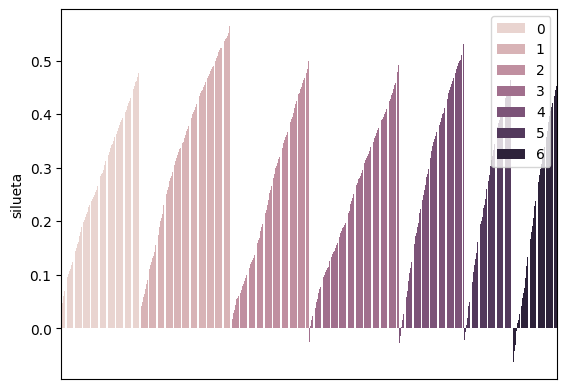

np.float64(0.2738000774649208)

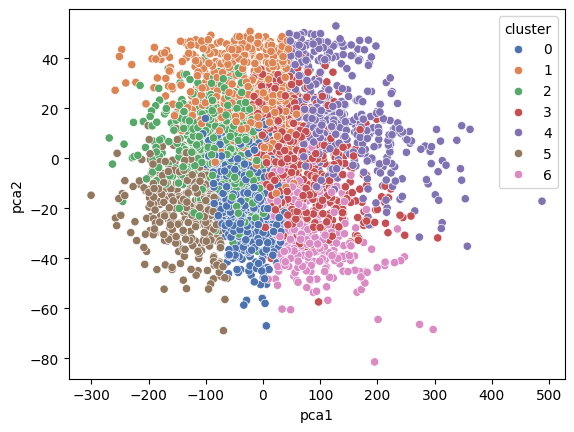

In [ ]:
# Voy a evaluar el modelo con la silueta
# Voy a empezar por calcular las siluetas para cada una de las observaciones
s_ob=silhouette_samples(xs, kresults.labels_)
s_ob

# Voy a crear un dataframe con datos
silu_obs=pd.DataFrame({'cluster':kresults.labels_ ,'silueta':s_ob, 'Purchase_made':base5['Purchase_Made']})
silu_obs.head()

# Organizar en orden asceendente por cluster y silueta
silu_obs.sort_values(['cluster','silueta'], inplace=True)
silu_obs

# Como ver todas las obs de un dataframe
pd.set_option('display.max_rows', None)
silu_obs

# Voy a crear un DataFrame donde tengo solo las obs con silueta negativa
# Es decir, las que fueron mal clasificadas
silu_neg=silu_obs[silu_obs['silueta']<0]
silu_neg

# Conteo de negativos por cluster
silu_neg.groupby('cluster').count()
silu_neg.value_counts('cluster')

#Grafica de barras por clusters
sns.barplot(data=silu_obs, x=range(len(silu_obs)), y='silueta', hue='cluster')
plt.xticks([])
plt.legend(loc='upper right')
plt.show()

# Para poder hacer la grafica completa de la silueta voy a usar descomposicion de componentes principales
from sklearn.decomposition import PCA
pca=PCA(n_components=2, random_state=42)
xs2=pca.fit_transform(x)
x_viz=pd.DataFrame(xs2, columns=['pca1','pca2'])
x_viz['cluster']=kresults.labels_
x_viz.head()

# Voy a hacer la grafica
sns.scatterplot(data=x_viz,
                x='pca1',
                y='pca2',
                hue='cluster',
                palette='deep')
plt

silhouette_score(xs,kresults.labels_)

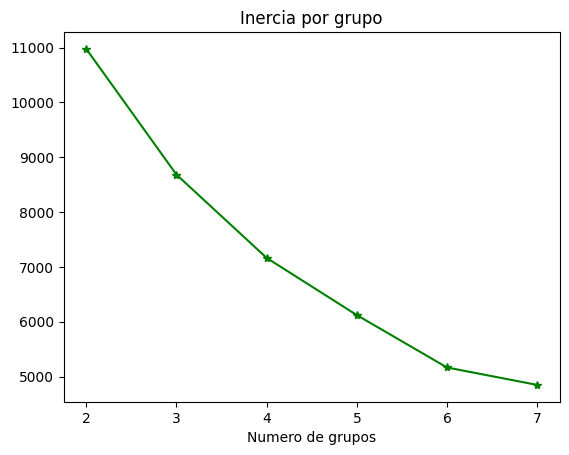

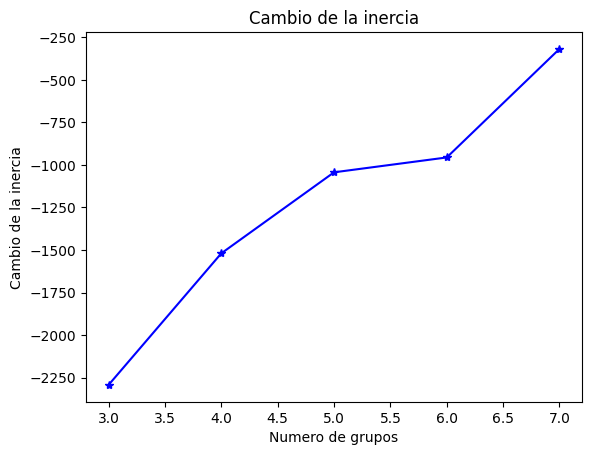

In [ ]:
#Voy a usar el metodo del codo
## El metodo del codo trata de evaluar la evolucion de otro atributo que es la inercia
#Voy a hacer un loop de igual manera
k_n=range(2,8)

inercia=[]

for k in k_n:
  KMeans3=KMeans(n_clusters=k,random_state=42)
  KMeans3.fit(xs)
  inercia.append(KMeans3.inertia_)

inercia

#Grafica de la inercia
plt.plot(k_n,inercia, marker="*",color="green")
plt.xlabel("Numero de grupos")
plt.title("Inercia por grupo")
plt.show()

#calcular el cambio en la pendiente
cambio=np.diff(inercia)
cambio

#graficar cambio de la inercia
plt.plot(
    k_n[1:],
    cambio,
    marker="*",
    color="blue")
plt.xlabel("Numero de grupos")
plt.ylabel("Cambio de la inercia")
plt.title("Cambio de la inercia")
plt.show()

